# 🎬 Movie Recommendation System — Complete End-to-End Pipeline

> **This notebook contains ALL project code** — from raw CSV ingestion and data cleaning, through
> exploratory analysis and feature engineering, to model training and serialization.
> The only separate file is `app.py` which runs the Streamlit web interface.

### Pipeline Stages
| # | Stage | Description |
|---|-------|-------------|
| 1 | **Imports & Setup** | Load all required libraries |
| 2 | **Data Loading** | Read `movies.csv` and `ratings.csv` |
| 3 | **Data Cleaning** | Handle nulls, duplicates, and genre formatting |
| 4 | **Feature Engineering** | Extract years, compute ratings, build tags |
| 5 | **EDA** | Visualize distributions and top movies |
| 6 | **Content-Based ML Model** | TF-IDF vectorization + Cosine Similarity |
| 7 | **Recommendation Engine** | Core recommendation functions |
| 8 | **Evaluation** | Test the engine with sample queries |
| 9 | **Model Export** | Serialize `.pkl` files to `models/` |

## 1. Imports & Setup

In [1]:
import os
import re
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_colwidth', 60)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading

We load two CSV files from the `dataset/` directory:
- **movies.csv** — `movieId`, `title`, `genres`
- **ratings.csv** — `userId`, `movieId`, `rating`, `timestamp`

In [2]:
DATASET_DIR = os.path.join('..', 'dataset')

movies_df = pd.read_csv(os.path.join(DATASET_DIR, 'movies.csv'))
ratings_df = pd.read_csv(os.path.join(DATASET_DIR, 'ratings.csv'))

print(f'Movies  : {movies_df.shape[0]:,} rows × {movies_df.shape[1]} columns')
print(f'Ratings : {ratings_df.shape[0]:,} rows × {ratings_df.shape[1]} columns')
print()
print('=== Movies (first 5 rows) ===')
display(movies_df.head())
print('=== Ratings (first 5 rows) ===')
display(ratings_df.head())

Movies  : 10,329 rows × 3 columns
Ratings : 105,339 rows × 4 columns

=== Movies (first 5 rows) ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


=== Ratings (first 5 rows) ===


,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


## 3. Data Cleaning

Steps performed:
- Check for **missing / null values** in both datasets
- Check for **duplicate rows** (movieId duplicates, full-row rating duplicates)
- Replace **`(no genres listed)`** with an empty string
- Drop any fully blank `genres` entries

In [3]:
# ── Null check ──────────────────────────────────────────────────────────────
print('Null values — movies:')
print(movies_df.isnull().sum(), '\n')
print('Null values — ratings:')
print(ratings_df.isnull().sum())

Null values — movies:
movieId    0
title      0
genres     0
dtype: int64 

Null values — ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [4]:
# ── Duplicate check ─────────────────────────────────────────────────────────
print(f'Duplicate movieIds  : {movies_df.duplicated(subset=["movieId"]).sum()}')
print(f'Duplicate rating rows: {ratings_df.duplicated().sum()}')

Duplicate movieIds  : 0
Duplicate rating rows: 0


In [5]:
# ── Genre cleaning ───────────────────────────────────────────────────────────
movies_df['genres'] = movies_df['genres'].fillna('').str.strip()

# Replace '(no genres listed)' with empty string
movies_df['genres'] = movies_df['genres'].replace('(no genres listed)', '')

# Drop rows with no title or empty title
movies_df = movies_df[movies_df['title'].notna() & (movies_df['title'].str.strip() != '')]
movies_df.reset_index(drop=True, inplace=True)

print(f'Clean movies shape: {movies_df.shape}')
movies_df.head()

Clean movies shape: (10329, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 4. Feature Engineering

Derived columns built in this stage:

| Column | Description |
|--------|-------------|
| `year` | Release year extracted from title with regex |
| `clean_title` | Title with year substring removed |
| `genres_list` | List of individual genre tokens |
| `genres_clean` | Space-joined genre string for TF-IDF |
| `avg_rating` | Mean user rating merged from ratings.csv |
| `num_ratings` | Total votes merged from ratings.csv |
| `weighted_rating` | Bayesian / IMDB-style weighted score |
| `tags` | `genres_clean + clean_title` — TF-IDF input |

In [6]:
# ── Helper functions ─────────────────────────────────────────────────────────
def extract_year(title):
    """Extract 4-digit year from parentheses in title."""
    m = re.search(r'\((\d{4})\)', str(title))
    return int(m.group(1)) if m else None

def clean_title(title):
    """Remove '(YYYY)' suffix and trailing whitespace."""
    return re.sub(r'\s*\(\d{4}\)', '', str(title)).strip()

# Apply helpers
movies_df['year'] = movies_df['title'].apply(extract_year)
movies_df['clean_title'] = movies_df['title'].apply(clean_title)
movies_df['genres_list'] = movies_df['genres'].apply(
    lambda g: g.split('|') if isinstance(g, str) and g != '' else []
)
movies_df['genres_clean'] = movies_df['genres_list'].apply(' '.join)

print('Year + title columns created.')
movies_df[['title', 'clean_title', 'year', 'genres_clean']].head()

Year + title columns created.


,title,clean_title,year,genres_clean
0,Toy Story (1995),Toy Story,1995.0,Adventure Animation Children Comedy Fantasy
1,Jumanji (1995),Jumanji,1995.0,Adventure Children Fantasy
2,Grumpier Old Men (1995),Grumpier Old Men,1995.0,Comedy Romance
3,Waiting to Exhale (1995),Waiting to Exhale,1995.0,Comedy Drama Romance
4,Father of the Bride Part II (1995),Father of the Bride Part II,1995.0,Comedy


In [7]:
# ── Aggregate rating statistics ──────────────────────────────────────────────
rating_stats = (
    ratings_df.groupby('movieId')
    .agg(avg_rating=('rating', 'mean'), num_ratings=('rating', 'count'))
    .reset_index()
)
rating_stats['avg_rating'] = rating_stats['avg_rating'].round(2)

movies_df = movies_df.merge(rating_stats, on='movieId', how='left')
movies_df['avg_rating'] = movies_df['avg_rating'].fillna(0.0)
movies_df['num_ratings'] = movies_df['num_ratings'].fillna(0).astype(int)

print('Rating stats merged.')
movies_df[['clean_title', 'avg_rating', 'num_ratings']].head()

Rating stats merged.


,clean_title,avg_rating,num_ratings
0,Toy Story,3.91,232
1,Jumanji,3.35,92
2,Grumpier Old Men,3.19,58
3,Waiting to Exhale,2.82,11
4,Father of the Bride Part II,3.25,62


In [8]:
# ── IMDB Bayesian Weighted Rating ─────────────────────────────────────────────
# Formula: WR = (v / (v+m)) * R + (m / (v+m)) * C
#   v = vote count for a movie
#   m = minimum votes required (60th percentile)
#   R = average rating for the movie
#   C = global mean rating across all movies

C = movies_df['avg_rating'].mean()
m = movies_df['num_ratings'].quantile(0.60)

def weighted_rating(row, m=m, C=C):
    v, R = row['num_ratings'], row['avg_rating']
    return round((v / (v + m)) * R + (m / (v + m)) * C, 2) if (v + m) > 0 else 0.0

movies_df['weighted_rating'] = movies_df.apply(weighted_rating, axis=1)

print(f'Global mean rating C = {C:.3f}')
print(f'Min votes threshold m = {m:.0f}')
movies_df[['clean_title', 'avg_rating', 'num_ratings', 'weighted_rating']].head(8)

Global mean rating C = 3.176
Min votes threshold m = 4


,clean_title,avg_rating,num_ratings,weighted_rating
0,Toy Story,3.91,232,3.90
1,Jumanji,3.35,92,3.34
2,Grumpier Old Men,3.19,58,3.19
3,Waiting to Exhale,2.82,11,2.91
4,Father of the Bride Part II,3.25,62,3.25
5,Heat,4.07,115,4.04
6,Sabrina,3.38,55,3.37
7,Tom and Huck,3.67,3,3.39


In [9]:
# ── Build TF-IDF tag column ───────────────────────────────────────────────────
movies_df['tags'] = movies_df['genres_clean'] + ' ' + movies_df['clean_title']
movies_df['tags'] = movies_df['tags'].str.strip()

print('Final engineered dataframe sample:')
movies_df[['movieId', 'clean_title', 'year', 'genres_clean', 'avg_rating',
           'num_ratings', 'weighted_rating', 'tags']].head()

Final engineered dataframe sample:


,movieId,clean_title,year,genres_clean,avg_rating,num_ratings,weighted_rating,tags
0,1,Toy Story,1995.0,Adventure Animation Children Comedy Fantasy,3.91,232,3.90,Adventure Animation Children Comedy Fantasy Toy Story
1,2,Jumanji,1995.0,Adventure Children Fantasy,3.35,92,3.34,Adventure Children Fantasy Jumanji
2,3,Grumpier Old Men,1995.0,Comedy Romance,3.19,58,3.19,Comedy Romance Grumpier Old Men
3,4,Waiting to Exhale,1995.0,Comedy Drama Romance,2.82,11,2.91,Comedy Drama Romance Waiting to Exhale
4,5,Father of the Bride Part II,1995.0,Comedy,3.25,62,3.25,Comedy Father of the Bride Part II


## 5. Exploratory Data Analysis (EDA)

C:\Users\user\AppData\Local\Temp\ipykernel_32820\3951051543.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_voted, y='clean_title', x='num_ratings', ax=axes[1, 0], palette='crest')
C:\Users\user\AppData\Local\Temp\ipykernel_32820\3951051543.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_wr, y='clean_title', x='weighted_rating', ax=axes[1, 1], palette='flare')


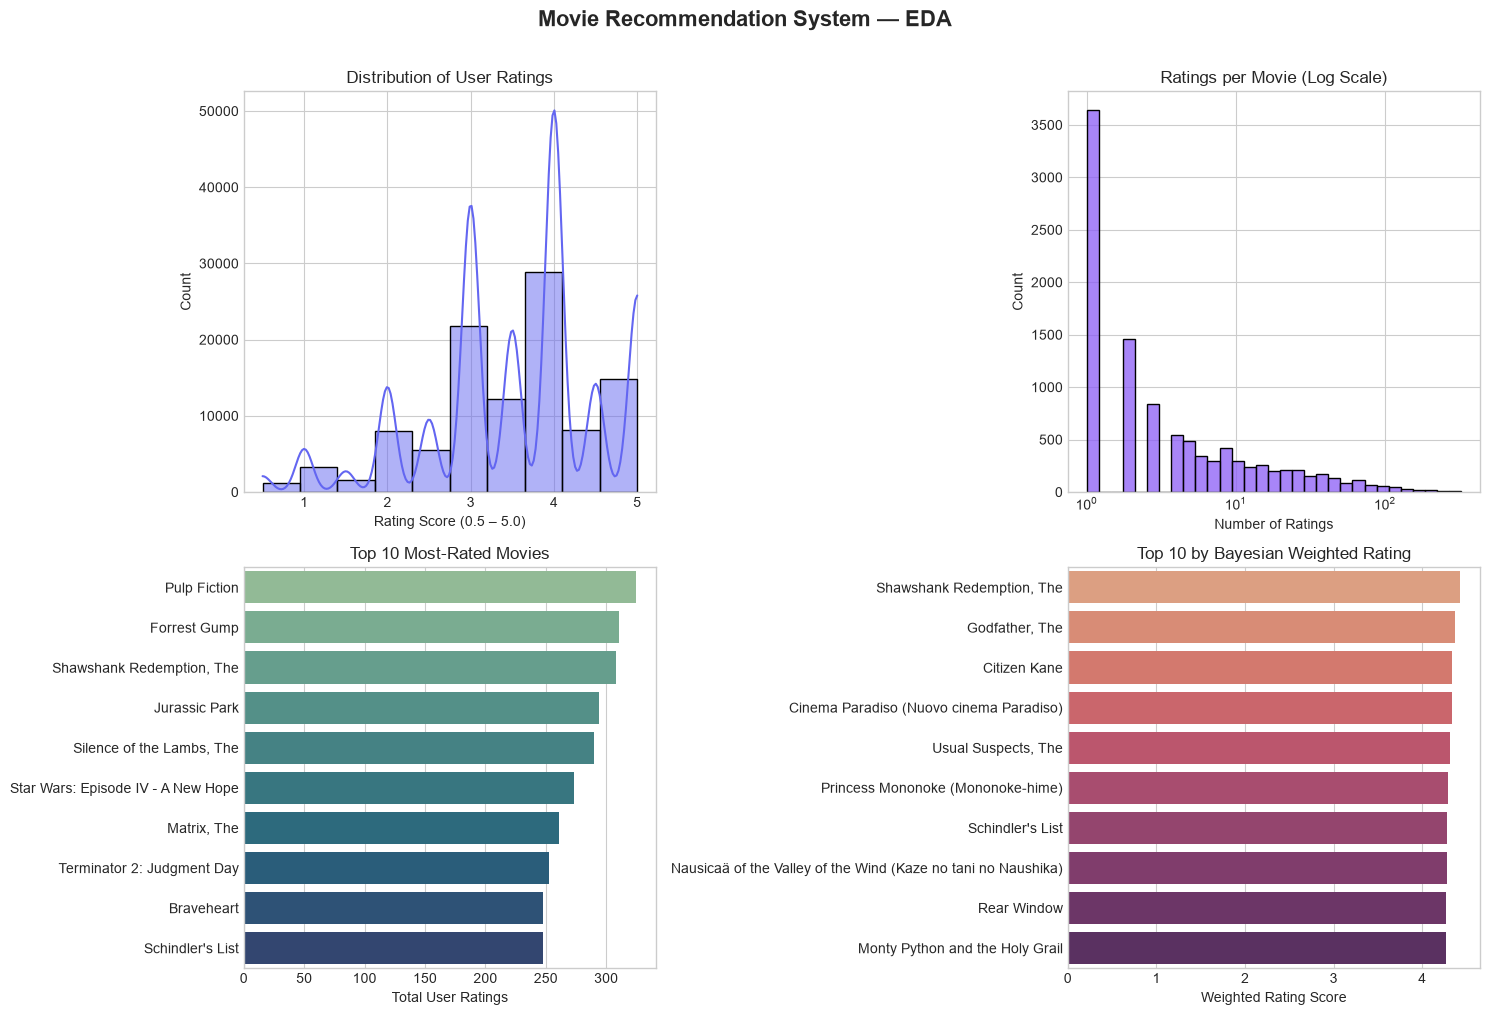

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Movie Recommendation System — EDA', fontsize=16, fontweight='bold', y=1.01)

# ① Rating score distribution
sns.histplot(ratings_df['rating'], bins=10, kde=True, ax=axes[0, 0], color='#6366f1')
axes[0, 0].set_title('Distribution of User Ratings')
axes[0, 0].set_xlabel('Rating Score (0.5 – 5.0)')

# ② Ratings per movie (log scale)
rated = movies_df[movies_df['num_ratings'] > 0]
sns.histplot(rated['num_ratings'], log_scale=True, ax=axes[0, 1], color='#8b5cf6')
axes[0, 1].set_title('Ratings per Movie (Log Scale)')
axes[0, 1].set_xlabel('Number of Ratings')

# ③ Top 10 most-rated movies
top_voted = movies_df.nlargest(10, 'num_ratings')
sns.barplot(data=top_voted, y='clean_title', x='num_ratings', ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('Top 10 Most-Rated Movies')
axes[1, 0].set_xlabel('Total User Ratings')
axes[1, 0].set_ylabel('')

# ④ Top 10 by weighted rating
top_wr = movies_df.nlargest(10, 'weighted_rating')
sns.barplot(data=top_wr, y='clean_title', x='weighted_rating', ax=axes[1, 1], palette='flare')
axes[1, 1].set_title('Top 10 by Bayesian Weighted Rating')
axes[1, 1].set_xlabel('Weighted Rating Score')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_32820\1022284346.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts, x='Genre', y='Count', palette='viridis')


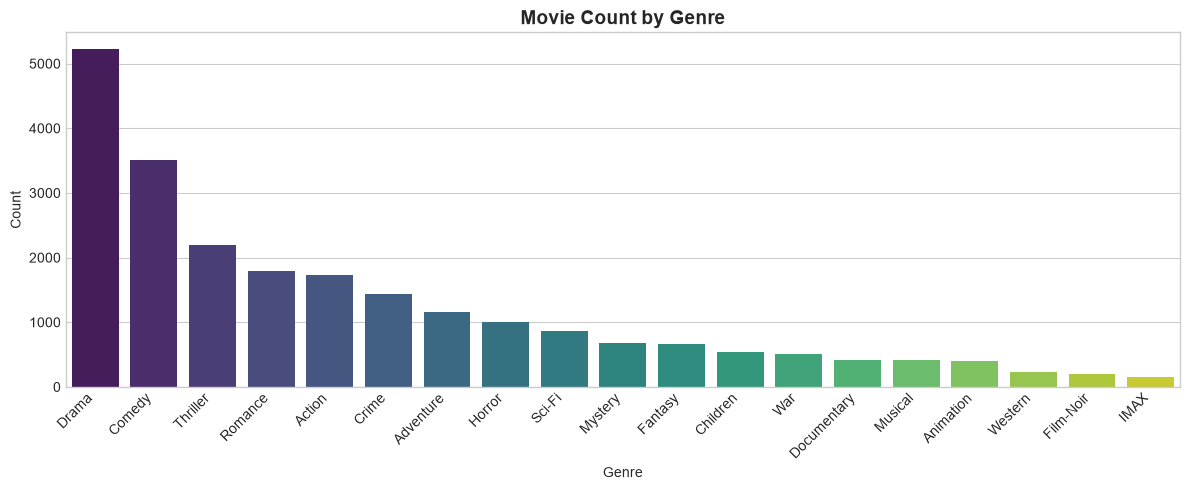

Unique genres: 19


In [11]:
# ── Genre distribution ────────────────────────────────────────────────────────
from collections import Counter

all_genres = [g for sublist in movies_df['genres_list'] for g in sublist if g]
genre_counts = pd.DataFrame(Counter(all_genres).most_common(), columns=['Genre', 'Count'])

plt.figure(figsize=(12, 5))
sns.barplot(data=genre_counts, x='Genre', y='Count', palette='viridis')
plt.title('Movie Count by Genre', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Unique genres: {len(genre_counts)}')

## 6. Content-Based ML Model — TF-IDF + Cosine Similarity

**Algorithm:**
1. Build a vocabulary from all movie `tags` (genre tokens + title words).
2. Represent every movie as a sparse TF-IDF vector.
3. Compute pairwise **cosine similarity** — similar genre/title movies score close to 1.
4. For fast inference, precompute and store only the **top-100 neighbors** per movie.

In [12]:
# ── TF-IDF Vectorizer ────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(movies_df['tags'])

print(f'TF-IDF Matrix : {tfidf_matrix.shape[0]:,} movies × {tfidf_matrix.shape[1]:,} features')
print(f'Sparsity      : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.2%}')

TF-IDF Matrix : 10,329 movies × 5,000 features
Sparsity      : 99.92%


In [13]:
# ── Cosine Similarity Matrix ─────────────────────────────────────────────────
sim_matrix = cosine_similarity(tfidf_matrix).astype(np.float32)
print(f'Similarity Matrix Shape : {sim_matrix.shape}')

Similarity Matrix Shape : (10329, 10329)


In [14]:
# ── Compress to top-100 neighbors per movie ──────────────────────────────────
# This reduces the stored object from ~800 MB to ~8 MB.
TOP_K = 100
n = sim_matrix.shape[0]
top_indices = np.zeros((n, TOP_K), dtype=np.int32)
top_scores  = np.zeros((n, TOP_K), dtype=np.float32)

for i in range(n):
    raw_idx    = np.argpartition(sim_matrix[i], -TOP_K)[-TOP_K:]
    sorted_idx = raw_idx[np.argsort(-sim_matrix[i][raw_idx])]
    top_indices[i] = sorted_idx
    top_scores[i]  = sim_matrix[i][sorted_idx]

similarity_data = {'top_indices': top_indices, 'top_scores': top_scores}
print('Top-100 similarity neighbors computed and stored.')

Top-100 similarity neighbors computed and stored.


## 7. Recommendation Engine Functions

All recommendation logic lives here. `app.py` loads the pickled models and calls similar logic directly.

In [15]:
def get_all_genres(df):
    """Return sorted list of all unique genres in the dataset."""
    genres = {g for sublist in df['genres_list'] for g in sublist if g}
    return sorted(genres)


def get_recommendations(title, top_n=10, genre_filter=None, min_rating=0.0):
    """
    Content-based recommendations using precomputed cosine similarity.

    Parameters
    ----------
    title        : str  — Exact movie title from movies_df
    top_n        : int  — Number of recommendations to return
    genre_filter : str  — Optional genre to restrict results
    min_rating   : float — Minimum avg_rating threshold

    Returns
    -------
    pd.DataFrame with recommended movies and similarity scores
    """
    matched = movies_df[movies_df['title'] == title]
    if matched.empty:
        matched = movies_df[movies_df['title'].str.contains(title, case=False, regex=False)]
    if matched.empty:
        return pd.DataFrame()

    idx = matched.index[0]
    indices = similarity_data['top_indices'][idx]
    scores  = similarity_data['top_scores'][idx]

    recs = []
    for neighbor_idx, score in zip(indices, scores):
        if neighbor_idx == idx:
            continue
        row = movies_df.iloc[neighbor_idx].copy()
        row['similarity_score'] = round(float(score) * 100, 1)
        if row['avg_rating'] < min_rating:
            continue
        if genre_filter and genre_filter not in row['genres_list']:
            continue
        recs.append(row)
        if len(recs) >= top_n:
            break

    return pd.DataFrame(recs) if recs else pd.DataFrame()


def get_popular_movies(top_n=10, genre_filter=None, min_votes=20):
    """
    Return top movies ranked by Bayesian weighted rating.
    """
    df = movies_df[movies_df['num_ratings'] >= min_votes]
    if genre_filter:
        df = df[df['genres_list'].apply(lambda gl: genre_filter in gl)]
    return df.nlargest(top_n, 'weighted_rating').reset_index(drop=True)


def get_random_movie(min_rating=3.5, min_votes=30):
    """Pick a random high-quality movie (for Surprise Me feature)."""
    pool = movies_df[(movies_df['avg_rating'] >= min_rating) &
                     (movies_df['num_ratings'] >= min_votes)]
    if pool.empty:
        pool = movies_df
    return pool.sample(1).iloc[0]['title']


print('Recommendation functions defined.')

Recommendation functions defined.


## 8. Recommendation Engine Evaluation

We test the engine on three well-known films across different genres.

In [16]:
test_titles = ['Toy Story (1995)', 'Fargo (1996)', 'Pulp Fiction (1994)']

for title in test_titles:
    recs = get_recommendations(title, top_n=5)
    if recs.empty:
        print(f"No results for '{title}'")
        continue
    print(f"\n{'='*60}")
    print(f"  Top 5 recommendations for: {title}")
    print(f"{'='*60}")
    display(recs[['title', 'genres', 'avg_rating', 'similarity_score']].reset_index(drop=True))


  Top 5 recommendations for: Toy Story (1995)


,title,genres,avg_rating,similarity_score
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,3.91,100.0
1,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,4.14,92.8
2,"Toy, The (1982)",Comedy,4.00,67.0
3,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,3.32,60.5
4,"Boxtrolls, The (2014)",Adventure|Animation|Children|Comedy|Fantasy,4.50,60.5



  Top 5 recommendations for: Fargo (1996)


,title,genres,avg_rating,similarity_score
0,Cul-de-sac (1966),Comedy|Crime|Drama|Thriller,5.00,44.5
1,In Bruges (2008),Comedy|Crime|Drama|Thriller,3.77,44.5
2,Get Shorty (1995),Comedy|Crime|Thriller,3.49,41.6
3,Snatch (2000),Comedy|Crime|Thriller,4.07,41.6
4,Shadowboxer (2005),Crime|Drama|Thriller,2.00,40.0



  Top 5 recommendations for: Pulp Fiction (1994)


,title,genres,avg_rating,similarity_score
0,Stranger than Fiction (2006),Comedy|Drama|Fantasy|Romance,3.80,67.6
1,In Bruges (2008),Comedy|Crime|Drama|Thriller,3.77,46.0
2,Cul-de-sac (1966),Comedy|Crime|Drama|Thriller,5.00,46.0
3,Get Shorty (1995),Comedy|Crime|Thriller,3.49,43.0
4,Snatch (2000),Comedy|Crime|Thriller,4.07,43.0


In [17]:
# Popular movies across all genres
print('=== Top 10 Popular Movies (All Genres) ===')
display(get_popular_movies(top_n=10)[['title', 'genres', 'avg_rating', 'num_ratings', 'weighted_rating']])

print('\n=== Top 5 Popular Sci-Fi Movies ===')
display(get_popular_movies(top_n=5, genre_filter='Sci-Fi')[['title', 'avg_rating', 'weighted_rating']])

print(f'\nRandom movie suggestion: {get_random_movie()}')

=== Top 10 Popular Movies (All Genres) ===


,title,genres,avg_rating,num_ratings,weighted_rating
0,"Shawshank Redemption, The (1994)",Crime|Drama,4.45,308,4.43
1,"Godfather, The (1972)",Crime|Drama,4.39,210,4.37
2,Citizen Kane (1941),Drama|Mystery,4.40,77,4.34
3,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,4.46,37,4.33
4,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.33,228,4.31
5,Princess Mononoke (Mononoke-hime) (1997),Action|Adventure|Animation|Drama|Fantasy,4.38,52,4.29
6,Schindler's List (1993),Drama|War,4.30,248,4.28
7,Nausicaä of the Valley of the Wind (Kaze no tani no Naus...,Adventure|Animation|Drama|Fantasy|Sci-Fi,4.48,22,4.28
8,Rear Window (1954),Mystery|Thriller,4.33,74,4.27
9,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,4.30,154,4.27



=== Top 5 Popular Sci-Fi Movies ===


,title,avg_rating,weighted_rating
0,Nausicaä of the Valley of the Wind (Kaze no tani no Naus...,4.48,4.28
1,"Matrix, The (1999)",4.26,4.24
2,Dr. Horrible's Sing-Along Blog (2008),4.43,4.24
3,Star Wars: Episode V - The Empire Strikes Back (1980),4.23,4.21
4,Star Wars: Episode IV - A New Hope (1977),4.19,4.18



Random movie suggestion: Harry Potter and the Half-Blood Prince (2009)


## 9. Model Export — Serialize to `models/`

Three pickle files are saved for use by `app.py`:

| File | Contents | Size |
|------|----------|------|
| `movie_list.pkl` | Full cleaned `movies_df` DataFrame | ~2 MB |
| `similarity.pkl` | Top-100 neighbor indices + scores | ~8 MB |
| `tfidf_vectorizer.pkl` | Fitted `TfidfVectorizer` | ~180 KB |

In [18]:
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

paths = {
    'movie_list.pkl'       : movies_df,
    'similarity.pkl'       : similarity_data,
    'tfidf_vectorizer.pkl' : tfidf,
}

for filename, obj in paths.items():
    fpath = os.path.join(MODELS_DIR, filename)
    with open(fpath, 'wb') as f:
        pickle.dump(obj, f)
    size_mb = os.path.getsize(fpath) / 1_000_000
    print(f'  Saved {filename:<28}  ({size_mb:.1f} MB)')

print('\nAll models serialized successfully.')

  Saved movie_list.pkl                (2.2 MB)
  Saved similarity.pkl                (8.3 MB)
  Saved tfidf_vectorizer.pkl          (0.2 MB)

All models serialized successfully.
